In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Set seed for reproducibility
np.random.seed(42)

# 1. Setup Base Timeline (30 days, hourly)
start_date = datetime(2026, 5, 1, 0, 0, 0)
total_hours = 30 * 24
timestamps = [start_date + timedelta(hours=i) for i in range(total_hours)]

# Define target areas/roads
roads = ['ROAD_001', 'ROAD_002', 'ROAD_003']

data_rows = []

for ts in timestamps:
    hour = ts.hour
    is_weekend = ts.weekday() >= 5
    
    # 2. Simulate Weather Factors First (independent variable)
    # Most days are clear, occasional rainy days
    is_rainy_day = (ts.day % 7 == 0) or (ts.day % 11 == 0)
    if is_rainy_day:
        rainfall = round(np.random.uniform(2.0, 15.0) if 8 <= hour <= 20 else np.random.uniform(0.5, 4.0), 1)
        visibility = round(np.random.uniform(2.0, 6.0), 1)
    else:
        # Occasional light morning drizzle/fog
        rainfall = round(np.random.uniform(0.0, 1.5) if (5 <= hour <= 8 and np.random.rand() > 0.8) else 0.0, 1)
        visibility = round(np.random.uniform(8.0, 10.0) if rainfall == 0 else np.random.uniform(5.0, 7.0), 1)
        
    temperature = round(22 + 8 * np.sin((hour - 6) * np.pi / 12) + np.random.uniform(-2, 2), 1)

    # 3. Simulate Traffic and Environment per Road
    for road in roads:
        # Base traffic profile depending on hour and road characteristics
        if is_weekend:
            # Weekend peak is smoother, afternoon heavy
            base_traffic = 300 + 400 * np.sin((hour - 11) * np.pi / 12)**2
        else:
            # Weekday twin peaks (Rush hours at 9 AM and 6 PM)
            base_traffic = 200 + 700 * np.exp(-((hour - 9)/2.5)**2) + 800 * np.exp(-((hour - 18)/2.5)**2)
            
        # Variations across different roads
        road_modifier = 1.2 if road == 'ROAD_001' else (0.8 if road == 'ROAD_003' else 1.0)
        vehicle_count = int(max(50, base_traffic * road_modifier + np.random.normal(0, 40)))
        
        # Speed drops based on vehicle volume and rainfall
        base_speed = 60 if road == 'ROAD_003' else 50  # Highway vs urban street
        speed_reduction_traffic = (vehicle_count / 1200) * 25
        speed_reduction_rain = rainfall * 1.5
        average_speed = round(max(10.0, base_speed - speed_reduction_traffic - speed_reduction_rain + np.random.normal(0, 3)), 1)
        
        # Congestion classification label
        if average_speed < 22:
            congestion_level = "Heavy"
        elif average_speed < 38:
            congestion_level = "Medium"
        else:
            congestion_level = "Low"

        # 4. Simulate Environmental Pollution (AQI Data)
        # Pollution scales heavily with vehicle count, decreases with rainfall (wash effect)
        base_pm25 = 15 + (vehicle_count / 1000) * 45 - (rainfall * 2.0)
        pm25 = round(max(5.0, base_pm25 + np.random.normal(0, 5)), 1)
        
        base_no2 = 10 + (vehicle_count / 1000) * 35 - (rainfall * 1.2)
        no2 = round(max(3.0, base_no2 + np.random.normal(0, 4)), 1)
        
        # Simple descriptive mapping for air status indicator
        max_pollutant = max(pm25, no2)
        if max_pollutant < 30:
            aqi_label = "Good"
        elif max_pollutant < 60:
            aqi_label = "Moderate"
        elif max_pollutant < 90:
            aqi_label = "Poor"
        else:
            aqi_label = "Hazardous"

        # Append structured row record
        data_rows.append({
            'timestamp': ts,
            'road_id': road,
            'vehicle_count': vehicle_count,
            'average_speed': average_speed,
            'congestion_level': congestion_level,
            'temperature_c': temperature,
            'rainfall_mm': rainfall,
            'visibility_km': visibility,
            'pm25_concentration': pm25,
            'no2_concentration': no2,
            'aqi_label': aqi_label
        })

# Convert structured records array to Pandas Dataframe
df_smart_city = pd.DataFrame(data_rows)

# Export generated datasets to individual clean CSV structures
df_smart_city[['timestamp', 'road_id', 'vehicle_count', 'average_speed', 'congestion_level']].to_csv('traffic_data.csv', index=False)
df_smart_city[['timestamp', 'temperature_c', 'rainfall_mm', 'visibility_km']].drop_duplicates().to_csv('weather_data.csv', index=False)
df_smart_city[['timestamp', 'road_id', 'pm25_concentration', 'no2_concentration', 'aqi_label']].to_csv('aqi_data.csv', index=False)

print("Data Generation Complete! Created three datasets:")
print("1. traffic_data.csv")
print("2. weather_data.csv")
print("3. aqi_data.csv")

Data Generation Complete! Created three datasets:
1. traffic_data.csv
2. weather_data.csv
3. aqi_data.csv


In [2]:
import pandas as pd

# 1. Load the individual CSV datasets
df_traffic = pd.read_csv('traffic_data.csv')
df_weather = pd.read_csv('weather_data.csv')
df_aqi = pd.read_csv('aqi_data.csv')

print("--- Step 1: Initial Shapes ---")
print(print(f"Traffic Data Shape: {df_traffic.shape}"))
print(f"Weather Data Shape: {df_weather.shape}")
print(f"AQI Data Shape:     {df_aqi.shape}\n")

# 2. Merge the datasets together
# First, we merge Traffic and AQI because they both share 'timestamp' AND 'road_id'
df_merged = pd.merge(df_traffic, df_aqi, on=['timestamp', 'road_id'], how='inner')

# Next, we merge the Weather data. Weather only depends on the 'timestamp' (shared across the whole city)
df_final = pd.merge(df_merged, df_weather, on='timestamp', how='inner')

print("--- Step 2: Merged Dataset Summary ---")
print(f"Final Combined Dataset Shape: {df_final.shape}\n")

# 3. Inspect the first 5 rows of our unified smart-city dataset
df_final.head()


--- Step 1: Initial Shapes ---
Traffic Data Shape: (2160, 5)
None
Weather Data Shape: (720, 4)
AQI Data Shape:     (2160, 5)

--- Step 2: Merged Dataset Summary ---
Final Combined Dataset Shape: (2160, 11)



,timestamp,road_id,vehicle_count,average_speed,congestion_level,pm25_concentration,no2_concentration,aqi_label,temperature_c,rainfall_mm,visibility_km
0,2026-05-01 00:00:00,ROAD_001,265,49.0,Low,25.8,18.3,Good,15.8,0.0,8.7
1,2026-05-01 00:00:00,ROAD_002,263,46.8,Low,24.5,21.4,Good,15.8,0.0,8.7
2,2026-05-01 00:00:00,ROAD_003,141,55.7,Low,22.6,7.3,Good,15.8,0.0,8.7
3,2026-05-01 01:00:00,ROAD_001,199,46.8,Low,19.4,11.3,Good,13.4,0.0,8.9
4,2026-05-01 01:00:00,ROAD_002,258,43.9,Low,26.9,13.3,Good,13.4,0.0,8.9


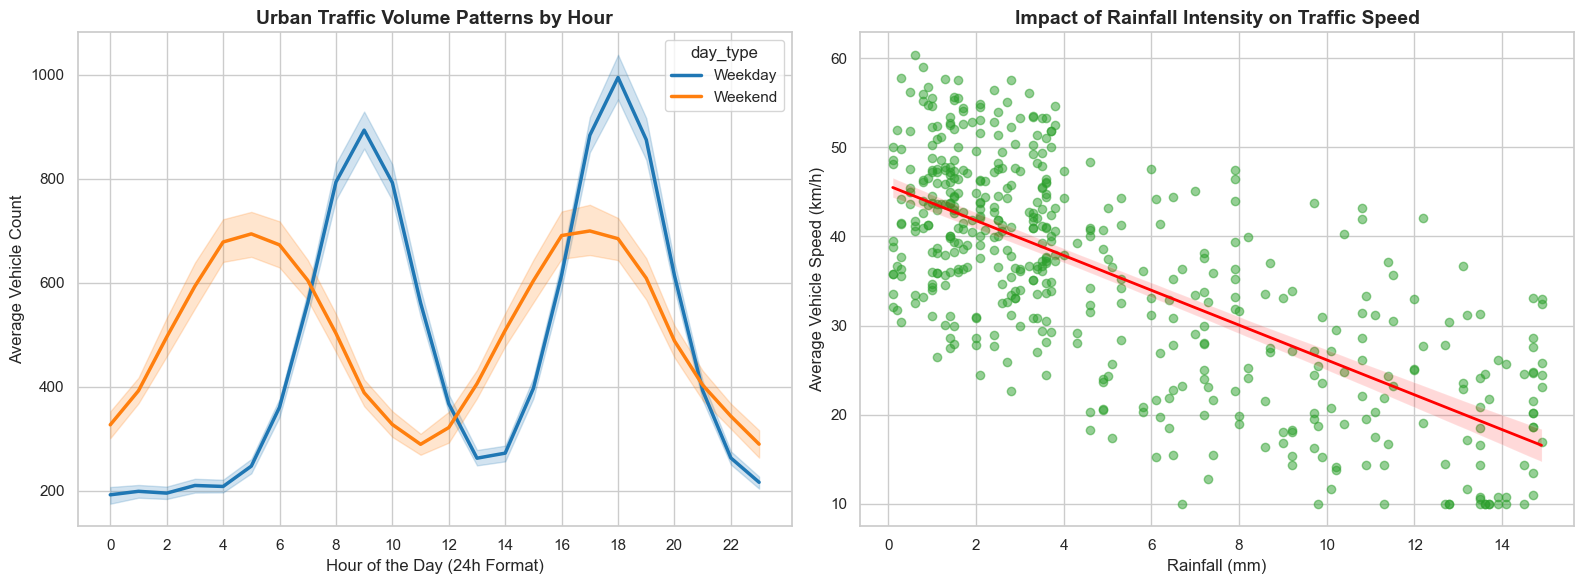

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure timestamps are treated as actual DateTime objects by Pandas
df_final['timestamp'] = pd.to_datetime(df_final['timestamp'])
df_final['hour'] = df_final['timestamp'].dt.hour
df_final['day_type'] = df_final['timestamp'].dt.dayofweek.apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

# Set up a clean, professional plotting style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Hourly Traffic Profile (Weekday vs Weekend) ---
sns.lineplot(
    data=df_final, 
    x='hour', 
    y='vehicle_count', 
    hue='day_type', 
    ax=axes[0], 
    linewidth=2.5,
    palette={'Weekday': '#1f77b4', 'Weekend': '#ff7f0e'}
)
axes[0].set_title('Urban Traffic Volume Patterns by Hour', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hour of the Day (24h Format)', fontsize=12)
axes[0].set_ylabel('Average Vehicle Count', fontsize=12)
axes[0].set_xticks(range(0, 24, 2))

# --- Plot 2: Impact of Rainfall on Vehicle Speeds ---
sns.regplot(
    data=df_final[df_final['rainfall_mm'] > 0], 
    x='rainfall_mm', 
    y='average_speed', 
    ax=axes[1],
    scatter_kws={'alpha':0.5, 'color': '#2ca02c'},
    line_kws={'color': 'red', 'linewidth': 2}
)
axes[1].set_title('Impact of Rainfall Intensity on Traffic Speed', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Rainfall (mm)', fontsize=12)
axes[1].set_ylabel('Average Vehicle Speed (km/h)', fontsize=12)

plt.tight_layout()
plt.show()

C:\Users\myida\AppData\Local\Temp\ipykernel_12064\360085144.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


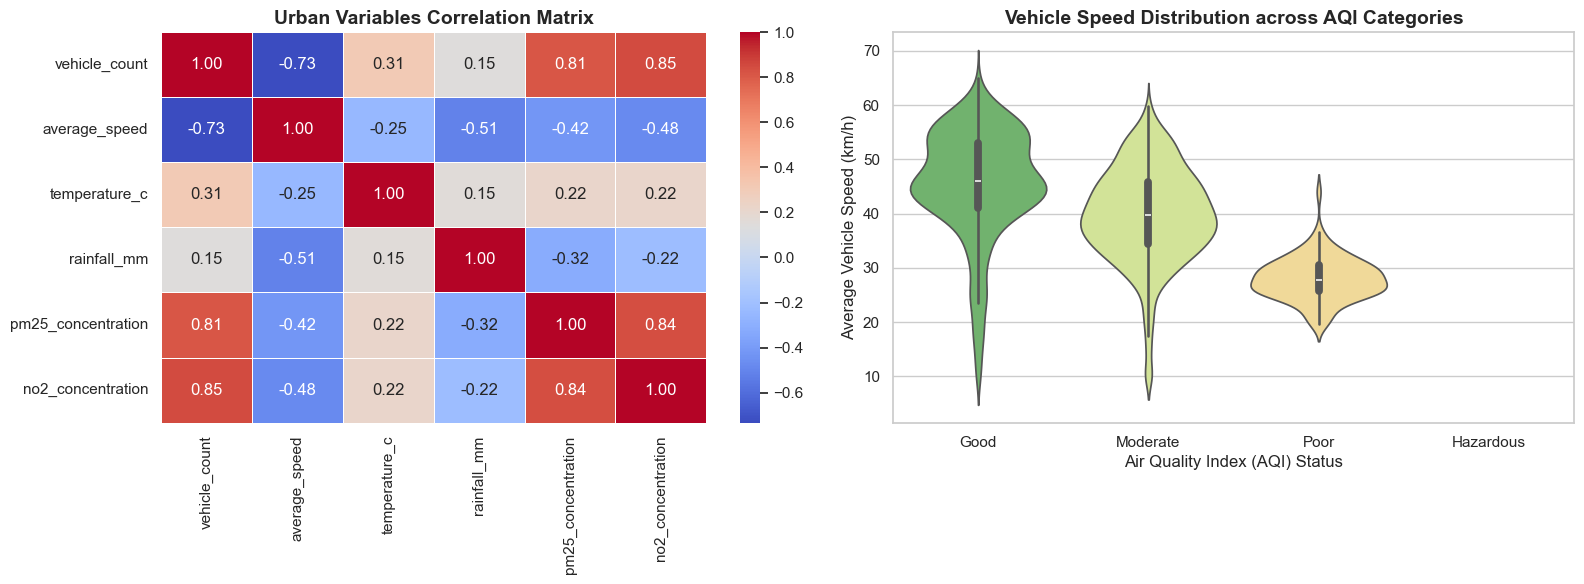

In [5]:
import numpy as np

# Set up a new figure layout
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Correlation Heatmap ---
# Select only numerical columns for correlation calculation
numerical_cols = ['vehicle_count', 'average_speed', 'temperature_c', 'rainfall_mm', 'pm25_concentration', 'no2_concentration']
corr_matrix = df_final[numerical_cols].corr()

sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5, 
    ax=axes[0]
)
axes[0].set_title('Urban Variables Correlation Matrix', fontsize=14, fontweight='bold')

# --- Plot 2: AQI vs Vehicle Speed Distribution ---
# Order the categorical labels cleanly
aqi_order = ['Good', 'Moderate', 'Poor', 'Hazardous']

sns.violinplot(
    data=df_final, 
    x='aqi_label', 
    y='average_speed', 
    order=aqi_order, 
    palette='RdYlGn_r', 
    ax=axes[1]
)
axes[1].set_title('Vehicle Speed Distribution across AQI Categories', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Air Quality Index (AQI) Status', fontsize=12)
axes[1].set_ylabel('Average Vehicle Speed (km/h)', fontsize=12)

plt.tight_layout()
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Feature Engineering: Select Predictors (X) and Target (y)
# We use hour, day_type, road_id, temperature, and rainfall to predict average_speed
X = df_final[['hour', 'day_type', 'road_id', 'temperature_c', 'rainfall_mm']]
y = df_final['average_speed']

# 2. One-Hot Encoding: Convert categorical text variables into binary columns (0 or 1)
X_encoded = pd.get_dummies(X, columns=['day_type', 'road_id'], drop_first=True)

# 3. Train-Test Split: Use 80% of data to train the model, and keep 20% hidden to test it
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print("--- Step 1: Data Splitting ---")
print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape:  {X_test.shape}\n")

# 4. Model Training: Initialize and fit the Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Model Evaluation: Make predictions on the test set and calculate metrics
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Step 2: Model Performance Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} km/h")
print(f"R-squared (Accuracy) Score: {r2 * 100:.2f}%")

--- Step 1: Data Splitting ---
Training Features Shape: (1728, 6)
Testing Features Shape:  (432, 6)

--- Step 2: Model Performance Metrics ---
Mean Absolute Error (MAE): 2.81 km/h
R-squared (Accuracy) Score: 87.39%


In [8]:
# --- 1. Extract Feature Importances from the Model ---
importances = model.feature_importances_
feature_names = X_encoded.columns

# Organize into a clean DataFrame
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Score': importances
}).sort_values(by='Importance_Score', ascending=False)

print("--- Step 1: What Drives Traffic Congestion? ---")
print(df_importance.to_string(index=False))
print("\n")

# --- 2. Create the Master Dataset for BI Tools ---
# We append our model's predictions as a new column back into the main dataset
# This allows us to compare 'Actual Speed' vs 'AI Predicted Speed' directly inside Power BI/Tableau
X_full_encoded = pd.get_dummies(X, columns=['day_type', 'road_id'], drop_first=True)
df_final['ai_predicted_speed'] = model.predict(X_full_encoded)

# Save this complete master dataset to a new CSV file
df_final.to_csv('urban_analytics_master.csv', index=False)

print("--- Step 2: Final File Ready ---")
print("Successfully generated 'urban_analytics_master.csv' with all features and AI predictions!")

--- Step 1: What Drives Traffic Congestion? ---
         Feature  Importance_Score
road_id_ROAD_003          0.387789
     rainfall_mm          0.300697
   temperature_c          0.142355
            hour          0.111374
day_type_Weekend          0.041832
road_id_ROAD_002          0.015952


--- Step 2: Final File Ready ---
Successfully generated 'urban_analytics_master.csv' with all features and AI predictions!
